テンソル総数      : 88
総メモリフットプリント: 9891.77 MB

最大テンソル:


,tensor_path,shape,dtype,n_elements,size_MB
16,mesh2grid_gnn/~_networks_builder/processor_edg...,"(195480, 1, 512)",float32,100085760,400.34304


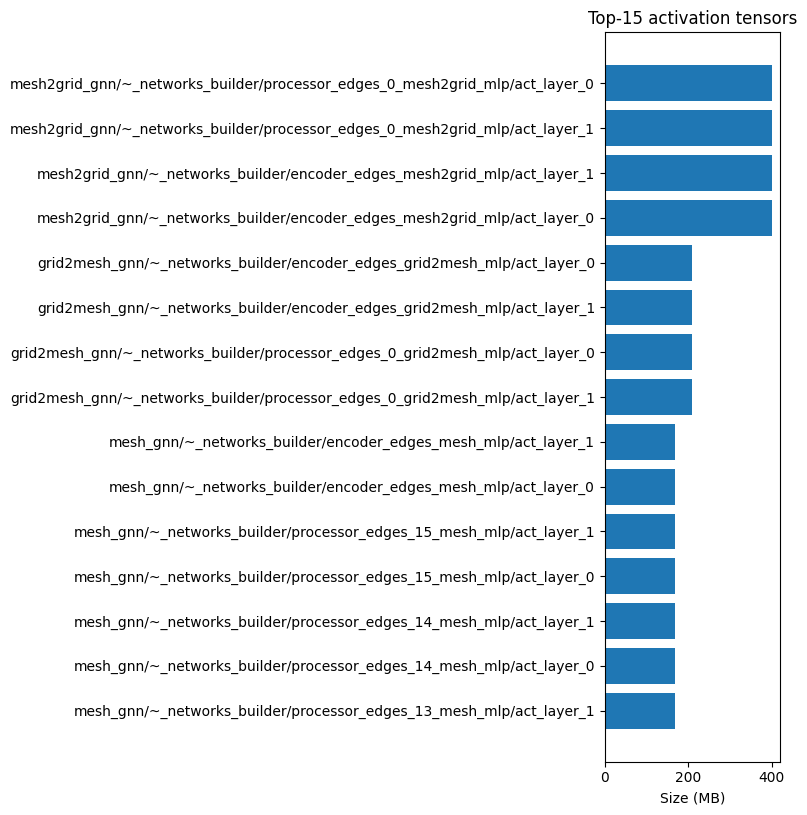

,tensor_path,shape,dtype,n_elements,size_MB
16,mesh2grid_gnn/~_networks_builder/processor_edges_0_mesh2grid_mlp/act_layer_0,"(195480, 1, 512)",float32,100085760,400.343040
17,mesh2grid_gnn/~_networks_builder/processor_edges_0_mesh2grid_mlp/act_layer_1,"(195480, 1, 512)",float32,100085760,400.343040
15,mesh2grid_gnn/~_networks_builder/encoder_edges_mesh2grid_mlp/act_layer_1,"(195480, 1, 512)",float32,100085760,400.343040
14,mesh2grid_gnn/~_networks_builder/encoder_edges_mesh2grid_mlp/act_layer_0,"(195480, 1, 512)",float32,100085760,400.343040
0,grid2mesh_gnn/~_networks_builder/encoder_edges_grid2mesh_mlp/act_layer_0,"(101892, 1, 512)",float32,52168704,208.674816
1,grid2mesh_gnn/~_networks_builder/encoder_edges_grid2mesh_mlp/act_layer_1,"(101892, 1, 512)",float32,52168704,208.674816
6,grid2mesh_gnn/~_networks_builder/processor_edges_0_grid2mesh_mlp/act_layer_0,"(101892, 1, 512)",float32,52168704,208.674816
7,grid2mesh_gnn/~_networks_builder/processor_edges_0_grid2mesh_mlp/act_layer_1,"(101892, 1, 512)",float32,52168704,208.674816
23,mesh_gnn/~_networks_builder/encoder_edges_mesh_mlp/act_layer_1,"(81900, 1, 512)",float32,41932800,167.731200
22,mesh_gnn/~_networks_builder/encoder_edges_mesh_mlp/act_layer_0,"(81900, 1, 512)",float32,41932800,167.731200


In [5]:
# --- 必要な import -------------------------------------------------
import pickle, os, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# --- 1️⃣ ファイルパスを自分の環境に合わせて変更 --------------------
pkl_path = Path("../../activations/source-era5_date-2022-01-01_res-1.0_levels-13_steps-01_final_state.pkl")
assert pkl_path.exists(), f"{pkl_path} が見つかりません。パスを修正してください。"

# --- 2️⃣ Haiku state をロード --------------------------------------
with pkl_path.open("rb") as f:
    state = pickle.load(f)

# --- 3️⃣ ネスト辞書 → DataFrame へ変換 ----------------------------
rows = []
def walk(d, prefix=""):
    for k, v in d.items():
        if isinstance(v, dict):
            walk(v, f"{prefix}{k}/")
        else:
            arr = np.asarray(v)
            rows.append({
                "tensor_path": f"{prefix}{k}",
                "shape": arr.shape,
                "dtype": arr.dtype,
                "n_elements": arr.size,
                "size_MB": arr.nbytes / 1e6
            })
walk(state)
df = pd.DataFrame(rows).sort_values("size_MB", ascending=False)

# --- 4️⃣ 概要表示 ---------------------------------------------------
print(f"テンソル総数      : {len(df)}")
print(f"総メモリフットプリント: {df['size_MB'].sum():.2f} MB")
print("\n最大テンソル:")
display(df.head(1))

# --- 5️⃣ 上位15テンソルを棒グラフ -----------------------------------
top = df.head(15)
plt.figure(figsize=(8, 0.35*len(top)+3))
plt.barh(range(len(top))[::-1], top["size_MB"])
plt.yticks(range(len(top))[::-1], top["tensor_path"])
plt.xlabel("Size (MB)")
plt.title("Top-15 activation tensors")
plt.tight_layout()
plt.show()

# --- 6️⃣ DataFrame をスクロール付きで見たい場合 --------------------
from IPython.display import display, HTML
display(HTML(df.to_html(max_rows=30, max_cols=5)))


stage
mesh_gnn         6374.080512
mesh2grid_gnn    2065.299552
grid2mesh_gnn    1452.392448
Name: size_MB, dtype: float64


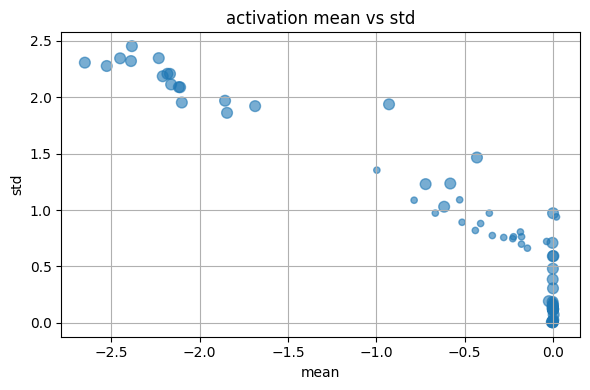

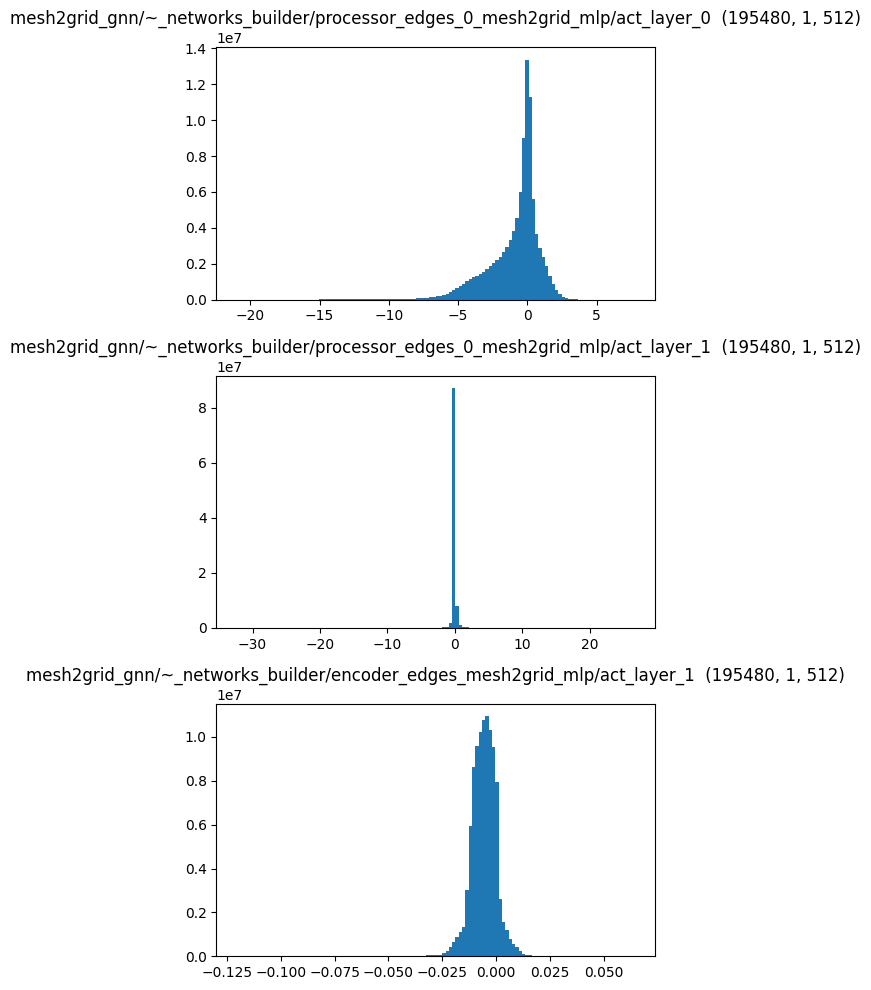

INT8 weight-only なら → 9891.8 MB → 2472.9 MB  (×4.0 圧縮)


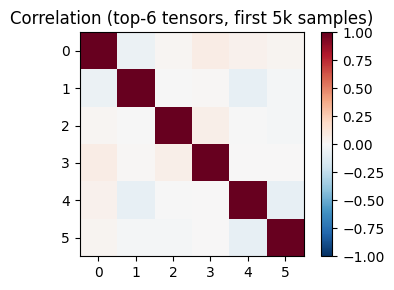

INT8 擬似量子化 (scale=0.05) RMSE ≈ 4.307e-01


In [10]:
import pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from itertools import islice

# --- flatten → DataFrame -------------------------------------------------
rows=[]
def walk(d, prefix=""):
    for k,v in d.items():
        walk(v, f"{prefix}{k}/") if isinstance(v, dict) else rows.append({
            "tensor_path":f"{prefix}{k}",
            "arr": np.asarray(v)                # ← 配列そのものも保持
        })
walk(state)
df = pd.DataFrame(rows)
df["shape"]   = df.arr.map(lambda a: a.shape)
df["size_MB"] = df.arr.map(lambda a: a.nbytes/1e6)
df["mean"]    = df.arr.map(np.mean)
df["std"]     = df.arr.map(np.std)

# --- ① stage 別メモリ ----------------------------------------------------
df["stage"] = df.tensor_path.str.extract(r'^(.*?gnn)/')[0]
print(df.groupby("stage")["size_MB"].sum().sort_values(ascending=False))

# --- ② mean-std 散布図 ---------------------------------------------------
plt.figure(figsize=(6,4))
plt.scatter(df["mean"], df["std"], s=np.clip(df["size_MB"],1,60), alpha=.6)
plt.xlabel("mean"); plt.ylabel("std"); plt.title("activation mean vs std")
plt.grid(True); plt.tight_layout(); plt.show()

# --- ③ トップ3テンソルのヒストグラム ------------------------------------
top3 = list(islice(df.sort_values("size_MB",ascending=False).itertuples(), 3))
plt.figure(figsize=(5,10))
for i,row in enumerate(top3,1):
    plt.subplot(3,1,i)
    plt.hist(row.arr.flatten(), bins=120)
    plt.title(f"{row.tensor_path}  {row.shape}")
plt.tight_layout(); plt.show()

# --- ④ INT8 weight-only 圧縮ざっくり ------------------------------------
orig = df["size_MB"].sum()
int8 = orig/4
print(f"INT8 weight-only なら → {orig:.1f} MB → {int8:.1f} MB  (×{orig/int8:.1f} 圧縮)")

# --- ⑤ おまけ: 層間相関ヒートマップ ------------------------------------
# 5000 サンプルだけ取って特徴相関を可視化
big   = df.sort_values("size_MB", ascending=False).head(6)
stack = np.stack([row.arr.flatten()[:5000] for row in big.itertuples()])
corr  = np.corrcoef(stack)
plt.figure(figsize=(4,3))
plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(); plt.xticks(range(6), range(6)); plt.yticks(range(6), range(6))
plt.title("Correlation (top-6 tensors, first 5k samples)")
plt.tight_layout(); plt.show()

# --- ⑥ おまけ: INT8 量子化誤差 quick check ---------------------------
def quantize(arr, scale):
    q = np.round(arr/scale).clip(-128,127)
    return q*scale

scale = .05   # 手動クリッピング幅
t     = big.iloc[0].arr        # 最も大きいテンソルで試す
err   = np.sqrt(np.mean((t - quantize(t,scale))**2))
print(f"INT8 擬似量子化 (scale={scale}) RMSE ≈ {err:.3e}")


In [11]:
import pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# ---------- flatten & collect extended stats ----------
rows=[]
def walk(tree, prefix=""):
    for k,v in tree.items():
        if isinstance(v, dict):
            walk(v, f"{prefix}{k}/")
        else:
            arr=np.asarray(v,dtype=np.float32).flatten()
            rows.append({
                "tensor_path":f"{prefix}{k}",
                "size_MB": arr.nbytes/1e6,
                "n_elems": arr.size,
                "mean": arr.mean(),
                "std":  arr.std(ddof=0),
                "skew": ((arr - arr.mean())**3).mean() / (arr.std(ddof=0)**3 + 1e-9),
                "kurt": ((arr - arr.mean())**4).mean() / (arr.var(ddof=0)**2 + 1e-9) - 3,
                "p01":  np.percentile(arr,1),
                "p50":  np.percentile(arr,50),
                "p99":  np.percentile(arr,99)
            })
walk(state)
stats = pd.DataFrame(rows).sort_values("size_MB",ascending=False)

# ---------- Show top‑30 rows ----------
from ace_tools import display_dataframe_to_user
display_dataframe_to_user("Activation extended statistics (top 30)", stats.head(30))

# ---------- Plot distributions of std, skew, kurt ----------
fig, axes = plt.subplots(1,3, figsize=(12,3))
axes[0].hist(stats["std"], bins=40);  axes[0].set_title("std distribution")
axes[1].hist(stats["skew"], bins=40); axes[1].set_title("skewness distribution")
axes[2].hist(stats["kurt"], bins=40); axes[2].set_title("kurtosis distribution")
plt.tight_layout(); plt.show()

# ---------- Identify outlier tensors (|skew|>2 or kurt>5) ----------
outliers = stats[(stats["skew"].abs()>2) | (stats["kurt"].abs()>5)]
display_dataframe_to_user("Outlier tensors by skew/kurtosis", outliers.head(50))


KeyboardInterrupt: 